## This ntebook handles preprocessing

In [1]:
%load_ext rpy2.ipython

Error importing in API mode: ImportError('On Windows, cffi mode "ANY" is only "ABI".')
Trying to import in ABI mode.


In [ ]:
%%R
library(haven)
df= read_sav("....sav")
df <- df[!is.na(df$Age) & df$Age >= 20, ]

# Count of missings
colSums(is.na(df))

# Percent of missnigs
round(colMeans(is.na(df)) * 100 ,2)

           Mean_Calcium           Mean_Phosphor          Mean_Magnesium 
                  27.41                   28.29                   28.40 
                    Age                     BMI                  Apache 
                   0.00                    6.91                    0.44 
              Sofa_Mean                  Status                     Sex 
                   0.33                    0.00                    0.00 
                  Smoky                     HTN                      DM 
                   0.11                    0.00                    0.00 
                    IHD                     CVA Pulmonary_Insufficiency 
                   0.11                    0.00                    0.00 
            Brain_Tumor      Ventilation_Status               Diagnosis 
                   0.00                    0.00                    0.00 


## Structure of Missings

In [4]:
%%R
library(naniar)
library(dplyr)
library(ggplot2)

# variables with missings
target_vars <- c("Mean_Calcium", "Mean_Phosphor", "Mean_Magnesium", "BMI", "Sofa_Mean", "Apache","Smoky","IHD")

# ==============================================================================
# First test: Test based on Outcome (Missingness Pattern by Outcome)
# ==============================================================================

# Percent of Missing based on Death and Discharge
miss_summary <- df %>%
  group_by(Status) %>%
  miss_var_summary() %>%
  filter(variable %in% target_vars)

print(miss_summary, n = 20)

# ==============================================================================
# Second test: MCAR test (Little's MCAR Test)
# ==============================================================================

# Runing the Little test on the variables
mcar_result <- mcar_test(df[, target_vars])
print(mcar_result)


# ==============================================================================
# Third test: MAR Test (Logistic regression for Predicting Missingness)
# ==============================================================================

# Create a binary indicator: whether calcium (as a key laboratory variable) is missing or not
df$Is_Calcium_Missing <- ifelse(is.na(df$Mean_Calcium), 1, 0)

# Logistic regression was conducted to determine whether disease severity (APACHEII/SOFA) 
# and mortality status influenced calcium missingness.
mar_model <- glm(Is_Calcium_Missing ~ Age + Status + Apache + Sofa_Mean, data = df, family = binomial)
print(summary(mar_model))

# A tibble: 16 x 4
# Groups:   Status [2]
   Status variable       n_miss pct_miss
    <dbl> <chr>           <int>    <num>
 1      1 Mean_Phosphor      47   21.2  
 2      1 Mean_Magnesium     47   21.2  
 3      1 Mean_Calcium       45   20.3  
 4      1 BMI                15    6.76 
 5      1 IHD                 1    0.450
 6      1 Apache              0    0    
 7      1 Sofa_Mean           0    0    
 8      1 Smoky               0    0    
 9      2 Mean_Magnesium    212   30.7  
10      2 Mean_Phosphor     211   30.6  
11      2 Mean_Calcium      205   29.7  
12      2 BMI                48    6.96 
13      2 Apache              4    0.580
14      2 Sofa_Mean           3    0.435
15      2 Smoky               1    0.145
16      2 IHD                 0    0    
# A tibble: 1 x 4
  statistic    df p.value missing.patterns
      <dbl> <dbl>   <dbl>            <int>
1      165.   118 0.00272               21

Call:
glm(formula = Is_Calcium_Missing ~ Age + Status + Apache + Sofa_Me


Attaching package: 'dplyr'

The following objects are masked from 'package:stats':

    filter, lag

The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union

Posit Community (formerly RStudio Community) is a great place to get
help: https://forum.posit.co/c/tidyverse


## Multipple Imputation and Nested croos validataion 

In [ ]:
%%R
# Cheking Colinearity before Multiple Imputation
library(car)
df_1 = df
df_1$Status <- ifelse(df_1$Status == 2, 0, 1)
model <- glm(Status ~ ., data = df_1, family = binomial)
round(vif(model),2)

           Mean_Calcium           Mean_Phosphor          Mean_Magnesium 
                   1.06                    1.16                    1.11 
                    Age                     BMI                  Apache 
                   1.66                    1.04                    1.87 
              Sofa_Mean                     Sex                   Smoky 
                   1.72                    1.31                    1.26 
                    HTN                      DM                     IHD 


                   1.44                    1.23                    1.07 
                    CVA Pulmonary_Insufficiency             Brain_Tumor 
                   1.10                    1.04                    1.03 
     Ventilation_Status               Diagnosis 
                   1.21                    1.23 


In [ ]:
%%R
library(mice)
library(caret)
library(haven)

continuous_vars <- c("Mean_Calcium", "Mean_Phosphor", "Mean_Magnesium", "Age", 
                     "BMI", "Sofa_Mean", "Apache")

binary_vars     <- c("Status", "Sex", "Smoky", "HTN", "DM", "IHD", "CVA", 
                     "Pulmonary_Insufficiency", "Brain_Tumor", "Ventilation_Status")

categorical_vars <- c("Diagnosis")

target_col <- "Status"

df[continuous_vars]  <- lapply(df[continuous_vars], as.numeric)
df[binary_vars]      <- lapply(df[binary_vars], as.factor)
df[categorical_vars] <- lapply(df[categorical_vars], as.factor)

# ── Shuffle ───────────────────────────────────────────────────────────────────
set.seed(123)
df <- df[sample(nrow(df)), ]

# ── 5 stratified folds ───────────────────────────────────────────────────────
folds <- createFolds(df[[target_col]], k = 5, list = TRUE, returnTrain = TRUE)

base_dir <- "./Imputed_Folds_test"
if (!dir.exists(base_dir)) dir.create(base_dir)

# ── Outer fold loop ───────────────────────────────────────────────────────────
for (i in 1:5) {
  cat(sprintf("\n========================================\n"))
  cat(sprintf("   Processing Fold %d  (80 / 20 split)\n", i))
  cat(sprintf("========================================\n"))

  fold_dir <- file.path(base_dir, paste0("Fold_", i))
  if (!dir.exists(fold_dir)) dir.create(fold_dir)

  train_idx  <- folds[[i]]
  train_data <- df[ train_idx, ]
  test_data  <- df[-train_idx, ]

  # ── Train imputation method map ───────────────────────────────────────────
  ini  <- mice(train_data, maxit = 0, printFlag = FALSE)
  meth <- ini$method
  meth[continuous_vars]  <- "pmm"
  meth[binary_vars]      <- "logreg"
  meth[categorical_vars] <- "polyreg"

  # ── TRAIN imputation (m=5) ────────────────────────────────────────────────
  # Status is real and known → use it as predictor for other missing columns
  cat("-> Imputing Train Data (m=5)...\n")
  mice_train_fit <- mice(train_data,
                         m         = 5,
                         maxit     = 10,
                         method    = meth,
                         seed      = 100 + i,
                         printFlag = FALSE)

  # ── Inner loop: one iteration per MICE model ──────────────────────────────
  for (m_idx in 1:5) {
    cat(sprintf("   -> Imputation version %d / 5\n", m_idx))

    # Extract this MICE draw of completed train
    complete_train <- complete(mice_train_fit, m_idx)

    # ── Stack complete train + test ───────────────────────────────────────
    # ignore = TRUE on test rows:
    #   → test rows are imputed but do NOT influence the imputation model
    #   → imputation model is built solely from train rows
    combined      <- rbind(complete_train, test_data)
    ignore_vector <- c(rep(FALSE, nrow(complete_train)),  # train → builds model
                       rep(TRUE,  nrow(test_data)))        # test  → only imputed

    # ── Build predictor matrix and zero out Status column ─────────────────
    # Status is unknown in test → must not be used as a predictor
    # This applies to all rows since it's one combined predictor matrix
    ini_combined          <- mice(combined, maxit = 0, printFlag = FALSE)
    pred_matrix           <- ini_combined$predictorMatrix
    pred_matrix[, target_col] <- 0   # no variable uses Status as predictor

    # ── TEST imputation (m=1) ─────────────────────────────────────────────
    cat(sprintf("   -> Imputing Test Data (version %d)...\n", m_idx))
    mice_test_fit <- mice(combined,
                          m               = 1,
                          maxit           = 10,
                          method          = meth,
                          predictorMatrix = pred_matrix,
                          ignore          = ignore_vector,
                          seed            = 200 + i * 10 + m_idx,
                          printFlag       = FALSE)

    complete_combined <- complete(mice_test_fit, 1)

    # ── Separate back into train and test ─────────────────────────────────
    final_train <- complete_combined[seq_len(nrow(complete_train)), ]
    final_test  <- complete_combined[(nrow(complete_train) + 1):nrow(complete_combined), ]

    # ── Restore real test Status (was in data but meaningless placeholder) ─
    final_test[[target_col]] <- test_data[[target_col]]

    # ── Tag rows ──────────────────────────────────────────────────────────
    final_train$Set_Type <- "Train"
    final_test$Set_Type  <- "Test"

    # ── Save ──────────────────────────────────────────────────────────────
    write_sav(final_train, file.path(fold_dir, sprintf("Train_Imputed_m%d.sav", m_idx)))
    write_sav(final_test,  file.path(fold_dir, sprintf("Test_Imputed_m%d.sav",  m_idx)))
  }

  cat(sprintf("   Dimensions -> Train: %d rows | Test: %d rows\n",
              nrow(final_train), nrow(final_test)))
  cat(sprintf("Success: Fold %d complete.\n", i))
}

cat("\n[Done] All 5 folds x 5 imputations = 50 files written.\n")


   Processing Fold 1  (80 / 20 split)
-> Imputing Train Data (m=5)...
   -> Imputation version 1 / 5
   -> Imputing Test Data (version 1)...
   -> Imputation version 2 / 5
   -> Imputing Test Data (version 2)...
   -> Imputation version 3 / 5
   -> Imputing Test Data (version 3)...
   -> Imputation version 4 / 5
   -> Imputing Test Data (version 4)...
   -> Imputation version 5 / 5
   -> Imputing Test Data (version 5)...
   Dimensions -> Train: 729 rows | Test: 183 rows
Success: Fold 1 complete.

   Processing Fold 2  (80 / 20 split)
-> Imputing Train Data (m=5)...
   -> Imputation version 1 / 5
   -> Imputing Test Data (version 1)...
   -> Imputation version 2 / 5
   -> Imputing Test Data (version 2)...
   -> Imputation version 3 / 5
   -> Imputing Test Data (version 3)...
   -> Imputation version 4 / 5
   -> Imputing Test Data (version 4)...
   -> Imputation version 5 / 5
   -> Imputing Test Data (version 5)...
   Dimensions -> Train: 730 rows | Test: 182 rows
Success: Fold 2 comple

Registered S3 method overwritten by 'lme4':
  method           from
  na.action.merMod car 

Attaching package: 'mice'

The following object is masked from 'package:stats':

    filter

The following objects are masked from 'package:base':

    cbind, rbind

Loading required package: lattice


In [ ]:
%%R
library(car)
library(haven)
# Cheking Colinearity after Multiple Imputation
# 1. Define predictors (exclude the target variable 'Status')
predictors <- c("Mean_Calcium", "Mean_Phosphor", "Mean_Magnesium", "Age", 
                "BMI", "Sofa_Mean", "Apache", "Sex", "Smoky", "HTN", 
                "DM", "IHD", "CVA", "Pulmonary_Insufficiency", 
                "Brain_Tumor", "Ventilation_Status", "Diagnosis")

# Construct the regression formula for VIF checking
vif_formula <- as.formula(paste("as.numeric(Status) ~", paste(predictors, collapse = " + ")))

# Initialize a list to store VIF values from each of the 5 imputed datasets
vif_list <- list()

cat("========================================\n")
cat("  Calculating VIF across 5 Imputations  \n")
cat("========================================\n")

# 2. Loop through all 5 imputed versions of Fold 1 (as a representative sample)
for (m_idx in 1:5) {
  file_path <- file.path("./Imputed_Folds_test/Fold_1", sprintf("Train_Imputed_m%d.sav", m_idx))
  train_data <- read_sav(file_path)
  
  # Ensure proper data types for factor variables
  train_data[binary_vars] <- lapply(train_data[binary_vars], as.factor)
  train_data[categorical_vars] <- lapply(train_data[categorical_vars], as.factor)
  
  # Fit a linear model to extract VIF statistics
  fit <- lm(vif_formula, data = train_data)
  
  # Calculate VIF (GVIF will be computed for multi-class variables like Diagnosis)
  vif_values <- vif(fit)
  
  # If a matrix is returned (due to GVIF), extract the first column (GVIF)
  if (is.matrix(vif_values)) {
    vif_list[[m_idx]] <- vif_values[, "GVIF"]
  } else {
    vif_list[[m_idx]] <- vif_values
  }
}

# 3. Aggregate and pool results by calculating the mean VIF across all imputations
vif_matrix <- do.call(cbind, vif_list)
mean_vif <- rowMeans(vif_matrix)

# Format the final results into a clean, sorted dataframe
vif_df <- data.frame(Variable = names(mean_vif), Mean_VIF = round(mean_vif, 2))
print(vif_df[order(-vif_df$Mean_VIF), ], row.names = FALSE)

cat("\n-> Interpretation: VIF > 5 indicates potential multicollinearity issues.\n")

  Calculating VIF across 5 Imputations  
                Variable Mean_VIF
                  Apache     3.55
               Sofa_Mean     2.82
      Ventilation_Status     1.81
                     Age     1.78
                     HTN     1.55
               Diagnosis     1.40
                     Sex     1.27
                      DM     1.26
                   Smoky     1.25
           Mean_Phosphor     1.15
                     IHD     1.12
          Mean_Magnesium     1.11
                     CVA     1.11
            Mean_Calcium     1.07
 Pulmonary_Insufficiency     1.05
             Brain_Tumor     1.05
                     BMI     1.04

-> Interpretation: VIF > 5 indicates potential multicollinearity issues.


## Sensitivity Analysis

In addition: Warning message:
Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
i Please use `linewidth` instead.
This warning is displayed once per session.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 


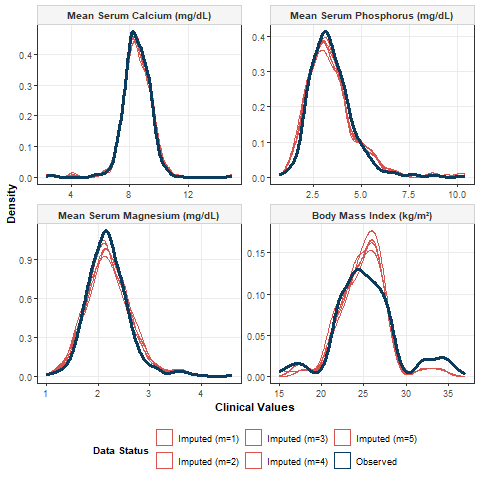

In [18]:
%%R
library(haven)
library(ggplot2)
library(caret)
library(dplyr)

# Reconstruction of Fold 1 to identify the true missing values.
set.seed(123)
folds <- createFolds(df$Status, k = 5, list = TRUE, returnTrain = TRUE)
original_train <- df[folds[[1]], ]


continuous_vars <- c("Mean_Calcium", "Mean_Phosphor", "Mean_Magnesium", "BMI")
plot_data <- data.frame()

# Extraction of the original and imputed data from local storage
for(var in continuous_vars) {
  
  # a) Original hospital data
  obs_vals <- original_train[[var]][!is.na(original_train[[var]])]
  if(length(obs_vals) > 0) {
    plot_data <- rbind(plot_data, data.frame(
      Value = obs_vals,
      Type = "Observed",
      Variable = var
    ))
  }
  
  # b) Values imputed by MICE from the five SAV files.
  for(m_idx in 1:5) {
    file_path <- file.path("./Imputed_Folds_New/Fold_1", paste0("Train_Imputed_m", m_idx, ".sav"))
    
    if(file.exists(file_path)) {
      imp_df <- read_sav(file_path)
      imp_vals <- imp_df[[var]][is.na(original_train[[var]])]
      
      if(length(imp_vals) > 0) {
        plot_data <- rbind(plot_data, data.frame(
          Value = imp_vals,
          Type = paste0("Imputed (m=", m_idx, ")"),
          Variable = var
        ))
      }
    }
  }
}

# Renaming variables using formal academic labels and measurement units
plot_data <- plot_data %>%
  mutate(Variable = case_when(
    Variable == "Mean_Calcium"   ~ "Mean Serum Calcium (mg/dL)",
    Variable == "Mean_Phosphor"  ~ "Mean Serum Phosphorus (mg/dL)",
    Variable == "Mean_Magnesium" ~ "Mean Serum Magnesium (mg/dL)",
    Variable == "BMI"            ~ "Body Mass Index (kg/m²)",
    TRUE                         ~ Variable
  )) %>%
  # Conversion of variables to factors to preserve the intended ordering in graphical displays
  mutate(Variable = factor(Variable, levels = c(
    "Mean Serum Calcium (mg/dL)", 
    "Mean Serum Phosphorus (mg/dL)", 
    "Mean Serum Magnesium (mg/dL)", 
    "Body Mass Index (kg/m²)"
  )))

# Generation of the final figures using a minimalistic
p <- ggplot(plot_data, aes(x = Value, color = Type, size = Type)) +
  geom_density(alpha = 0.08) +
  facet_wrap(~Variable, scales = "free", ncol = 2) +
  
  scale_color_manual(values = c(
    "Observed" = "#0B3C5D",  
    "Imputed (m=1)" = "#D9534F", "Imputed (m=2)" = "#D9534F", 
    "Imputed (m=3)" = "#D9534F", "Imputed (m=4)" = "#D9534F", 
    "Imputed (m=5)" = "#D9534F"
  )) +
  scale_size_manual(values = c(
    "Observed" = 1.2,
    "Imputed (m=1)" = 0.4, "Imputed (m=2)" = 0.4, 
    "Imputed (m=3)" = 0.4, "Imputed (m=4)" = 0.4, 
    "Imputed (m=5)" = 0.4
  )) +
  
  labs(x = "Clinical Values", 
       y = "Density", 
       color = "Data Status") +
  theme_bw() + 
  theme(
    strip.background = element_rect(fill = "#F5F5F5", color = "#D3D3D3"), 
    strip.text = element_text(face = "bold", size = 10, color = "#333333"),
    axis.title = element_text(face = "bold", size = 11),
    axis.text = element_text(size = 9),
    legend.position = "bottom",
    legend.title = element_text(face = "bold", size = 10),
    panel.grid.minor = element_blank() 
  ) +
  guides(size = "none")

print(p)

# saveing
ggsave("Imputation_Diagnostics_Final.tiff", 
       plot = p, 
       width = 10, 
       height = 8, 
       dpi = 300, 
       compression = "lzw") 

ggsave("Imputation_Diagnostics_Final.png", 
       plot = p, 
       width = 10, 
       height = 8, 
       dpi = 300)